In [5]:
import pandas as pd
import numpy as np

In [68]:
from pathlib import Path

project = Path.cwd()
print("current folder:", project)
print("\nFiles/folders here:")
for item in project.iterdir():
    print(item.name)

project_root = Path.cwd().parent
print("Parent folder:",project_root)

train_source1 = project_root / "data" / "raw" / "train" / "train_source1.tsv"
train_source2 = project_root / "data" / "raw" / "train" / "train_source2.tsv"
train_source3 = project_root / "data" / "raw" / "train" / "train_source3.tsv"

train1 = pd.read_csv(train_source1, sep="\t")
train2 = pd.read_csv(train_source2, sep="\t")
train3 = pd.read_csv(train_source3, sep="\t")

train_gr_truth = project_root / "data" / "raw" / "train" / "train_ground_truth.tsv"
train_gr = pd.read_csv(train_gr_truth, sep="\t")

test_source1 = project_root / "data" / "raw" / "test" / "test_source1.tsv"
test_source2 = project_root / "data" / "raw" / "test" / "test_source2.tsv"
test_source3 = project_root / "data" / "raw" / "test" / "test_source3.tsv"

test1 = pd.read_csv(test_source1, sep="\t")
test2 = pd.read_csv(test_source2, sep="\t")
test3 = pd.read_csv(test_source3, sep="\t")

current folder: C:\Users\chira\OneDrive\Desktop\amazon-ml-challenge-2026\notebooks

Files/folders here:
.ipynb_checkpoints
read_data.ipynb
understand_data.ipynb
Parent folder: C:\Users\chira\OneDrive\Desktop\amazon-ml-challenge-2026


In [7]:
train1.head()

,entity_id,business_name,business_address,country
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US
3,S1-133037285,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",US
4,S1-755362802,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West ...",India


<Axes: >

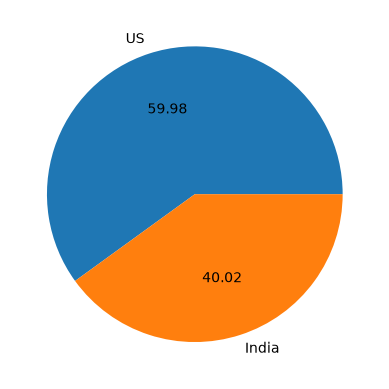

In [10]:
train1["country"].value_counts().plot(kind='pie',autopct="%.2f")

In [12]:
train1.shape, train2.shape, train3.shape, train_gr.shape

((2206821, 4), (5034616, 4), (5285603, 4), (2206821, 2))

In [13]:
train1.tail()

,entity_id,business_name,business_address,country
2206816,S1-479751630,Arlyn Farooqi Prairie Medical,"16804 Stevenage Street, Surprise, AZ",US
2206817,S1-392755726,Patriot Fund,"MD, 7709 Ashdale Road, Capitol Heights",US
2206818,S1-716147977,Sloan Fact of Yonkers,"28 Armstrong Avenue, Unit Apartment 2, Yonkers...",US
2206819,S1-770136229,Ritter's Machine Works,"5609 Spring Meadow Road, Austin, TX",US
2206820,S1-252639948,Abc Sangh Limited,"C/O. Yuken India Limited, B-80, 2Nd Cross, 1St...",India


In [14]:
train2.tail()

,entity_id,business_name,business_address,country
5034611,S2-147379319,CHOICE SECURITY PARTNERS CO,"IL, 023 Franklin St, DANVILLE",US
5034612,S2-828699622,TMQ Public (Center),"65 Fifth Street, FULTON, NY",US
5034613,S2-726846711,CONTINENTAL CDT PC,"SPENCER, MA, 18 GROVE ST",US
5034614,S2-115058866,लक्ष्मी मीडिया प्राइवेट लिमिटेड,"154, BHUGAON, PUNE, महाराष्ट्र",India
5034615,S2-955929147,Alphabet Inc.,"FLOWEREE, 277B PORTAGE ROAD, MT",US


In [15]:
train3.tail()

,entity_id,business_name,business_address,country
5285598,S3-549653960,Vip Solutions,NaN,India
5285599,S3-45212707,Cornerstone Nippon,"Paula Drive, Arkansas, N Little Rock",US
5285600,S3-257390113,Legacy Piedmont,"Portland, Maine, Forest Park",US
5285601,S3-97881155,Pranava Meribl Trust,"235, 13Th Cross Road, Hoyasala Ngr 2D Stage, B...",India
5285602,S3-864344230,The Trusted Defense Products Inc,NaN,US


In [16]:
train_gr.tail()

,source1_entity_id,matched_entity_ids
2206816,S1-824289006,S3-141788999
2206817,S1-856943494,"S2-950831962,S3-34095479,S3-718748776,S3-44048..."
2206818,S1-863031412,"S2-518155942,S2-631615245,S3-846786490,S3-1665..."
2206819,S1-711234676,"S2-908396708,S3-279383973,S3-969901413"
2206820,S1-474890318,"S2-271844502,S3-998262924"


In [22]:
train1.query('entity_id=="S1-856943494"')

,entity_id,business_name,business_address,country
659151,S1-856943494,Rapid Cloud Industries L.L.C.,"TX, Freeport, 523 Smith Lane",US


In [17]:
train2.query('entity_id=="S2-950831962"')

,entity_id,business_name,business_address,country
1970975,S2-950831962,Rapid Cloud Industries Llc,"523. SMITH LANE, FREEPORT, TX",US


In [20]:
train3.query('entity_id=="S3-34095479"')

,entity_id,business_name,business_address,country
1316137,S3-34095479,Rapid Cloud Industries-Llc,"523-D Smith Ln, Freeport, Texas",US


In [21]:
train3.query('entity_id=="S3-718748776"')

,entity_id,business_name,business_address,country
533175,S3-718748776,Rapid Cloud índustries L.L.C.,"523-D Smith Ln, Freeport, Texas",US


In [23]:
train1.describe()

,entity_id,business_name,business_address,country
count,2206821,2206821,2206821,2206821
unique,2206821,1539229,2130606,2
top,S1-925783039,Primary Care Group,"108 Norle Street, College Twp, PA",US
freq,1,253,14,1323633


In [28]:
train1.duplicated().sum()

np.int64(0)

In [30]:
train1.isna().sum().sum()

np.int64(0)

In [32]:
train2.duplicated().sum()

np.int64(0)

In [34]:
train2.isna().sum()

entity_id                0
business_name            2
business_address    168967
country                  0
dtype: int64

In [35]:
train3.duplicated().sum()

np.int64(0)

In [36]:
train3.isna().sum()

entity_id                0
business_name           13
business_address    175916
country                  0
dtype: int64

In [50]:
train_gr.isna().sum()

source1_entity_id          0
matched_entity_ids    123247
dtype: int64

In [39]:
print("\n Info")
print("\n info of train-1:\n", train1.info())
print("\n info of train-2:\n", train2.info())
print("\n info of train-3:\n", train3.info())


 Info
<class 'pandas.DataFrame'>
RangeIndex: 2206821 entries, 0 to 2206820
Data columns (total 4 columns):
 #   Column            Dtype
---  ------            -----
 0   entity_id         str  
 1   business_name     str  
 2   business_address  str  
 3   country           str  
dtypes: str(4)
memory usage: 67.3 MB

 info of train-1:
 None
<class 'pandas.DataFrame'>
RangeIndex: 5034616 entries, 0 to 5034615
Data columns (total 4 columns):
 #   Column            Dtype
---  ------            -----
 0   entity_id         str  
 1   business_name     str  
 2   business_address  str  
 3   country           str  
dtypes: str(4)
memory usage: 153.6 MB

 info of train-2:
 None
<class 'pandas.DataFrame'>
RangeIndex: 5285603 entries, 0 to 5285602
Data columns (total 4 columns):
 #   Column            Dtype
---  ------            -----
 0   entity_id         str  
 1   business_name     str  
 2   business_address  str  
 3   country           str  
dtypes: str(4)
memory usage: 161.3 MB

 inf

In [47]:
train2[train2['business_address'].isna()]

,entity_id,business_name,business_address,country
53,S2-187379771,"Guerra And Krueger Table, LLC",NaN,US
69,S2-751730544,L E Pierce Cal [PC],NaN,US
93,S2-162849450,Preferred Bay Montage Inc,NaN,US
195,S2-616836723,DELONG STRATEGIC READY,NaN,US
236,S2-39617527,Desert Vanguard ([Maintenance]),NaN,US
...,...,...,...,...
5034482,S2-640478364,Eye Medicine Inc,NaN,US
5034527,S2-956532552,Lacaze Translational,NaN,US
5034547,S2-25169598,Somil-Ventures,NaN,India
5034573,S2-243777054,Nivue Co,NaN,US


In [48]:
train3[train3['business_address'].isna()]

,entity_id,business_name,business_address,country
1,S3-859268022,International South Consultants Private Ltd,NaN,India
52,S3-92001570,Davis Acquisition,NaN,US
105,S3-299576808,"Morales, Godina & Pánkow Associates LLC",NaN,US
110,S3-924073964,The Nancy Nancy Bunten Energy,NaN,US
125,S3-588120445,Anand Agro Private Enterprises,NaN,India
...,...,...,...,...
5285411,S3-892300116,Li And Hinton LLC,NaN,US
5285435,S3-44609779,Crofts Modern Coinshares LLC,NaN,US
5285585,S3-655990255,Thompson Atlantic Machine Works,NaN,US
5285598,S3-549653960,Vip Solutions,NaN,India


In [52]:
train_gr[train_gr["matched_entity_ids"].isna()]

,source1_entity_id,matched_entity_ids
21,S1-302869473,NaN
37,S1-262997549,NaN
40,S1-508022910,NaN
51,S1-666499407,NaN
64,S1-965524997,NaN
...,...,...
2206763,S1-386385582,NaN
2206779,S1-472365900,NaN
2206797,S1-152817042,NaN
2206802,S1-286797376,NaN


In [69]:
print(train_gr.columns.tolist())
print(train_gr.head(10).to_string())
print(train_gr.dtypes)

print(train_gr['matched_entity_ids'].head(10).tolist())

['source1_entity_id', 'matched_entity_ids']
  source1_entity_id                                                             matched_entity_ids
0         S1-965667                S2-681193310,S2-743505751,S3-775321672,S3-11291185,S3-860443364
1       S1-55344266                            S2-249013014,S2-197070651,S3-478195123,S3-384364074
2      S1-343815751                                         S2-790675320,S2-479876582,S3-878454467
3      S1-656753428                                          S2-153058913,S2-24659151,S3-679606215
4      S1-102811957  S2-478959098,S2-553508714,S2-625774905,S3-728090388,S3-928796641,S3-449308785
5       S1-18727616                            S2-755677256,S3-187831601,S3-641489370,S3-476250621
6      S1-318373630                                                      S2-660036492,S3-804600254
7       S1-86989137                                                      S3-274817120,S3-312496301
8       S1-29845983                                              

In [70]:
ground_truth = {
    "S1-965667": {
        "S2-681193310",
        "S2-743505751",
        "S3-775321672",
        "S3-11291185",
        "S3-860443364"
    }
}

In [71]:
s1_id = "S1-965667"
candidate_id = "S2-681193310"

In [72]:
candidate_id in ground_truth[s1_id]

True

In [77]:
# Create ground-truth mapping
gt_mapping = {}

for _, row in train_gr.iterrows():
    s1_id = row["source1_entity_id"]
    matched = row["matched_entity_ids"]

    if pd.isna(matched):
        gt_mapping[s1_id] = set()
    else:
        gt_mapping[s1_id] = set(matched.split(","))

In [78]:
print(gt_mapping["S1-965667"])

{'S3-860443364', 'S3-775321672', 'S2-743505751', 'S3-11291185', 'S2-681193310'}


In [79]:
print("S2-681193310" in gt_mapping["S1-965667"])
print("S2-249013014" in gt_mapping["S1-965667"])

True
False


In [80]:
positive_pairs = []

for s1_id, matched_ids in gt_mapping.items():
    for matched_id in matched_ids:
        positive_pairs.append({
            "source1_entity_id": s1_id,
            "matched_entity_id": matched_id,
            "target": 1
        })

positive_pairs = pd.DataFrame(positive_pairs)

print(positive_pairs.head(10))
print("Positive pairs:", len(positive_pairs))

  source1_entity_id matched_entity_id  target
0         S1-965667      S3-860443364       1
1         S1-965667      S3-775321672       1
2         S1-965667      S2-743505751       1
3         S1-965667       S3-11291185       1
4         S1-965667      S2-681193310       1
5       S1-55344266      S3-478195123       1
6       S1-55344266      S3-384364074       1
7       S1-55344266      S2-249013014       1
8       S1-55344266      S2-197070651       1
9      S1-343815751      S2-479876582       1
Positive pairs: 7638365


In [81]:
positive_pairs.shape

(7638365, 3)

In [87]:
positive_pairs['target'].nunique()

1

In [88]:
positive_pairs["source"] = positive_pairs["matched_entity_id"].str[:2]

print(positive_pairs["source"].value_counts())

source
S3    3944746
S2    3693619
Name: count, dtype: int64


In [89]:
print(positive_pairs["matched_entity_id"].str[:2].value_counts())

matched_entity_id
S3    3944746
S2    3693619
Name: count, dtype: int64


In [90]:
matches_per_s1 = (
    positive_pairs
    .groupby("source1_entity_id")
    .size()
)

print(matches_per_s1.describe())

count    2.083574e+06
mean     3.665992e+00
std      1.526294e+00
min      1.000000e+00
25%      3.000000e+00
50%      4.000000e+00
75%      5.000000e+00
max      1.100000e+01
dtype: float64


In [92]:
positive_pairs.head()

,source1_entity_id,matched_entity_id,target,source
0,S1-965667,S3-860443364,1,S3
1,S1-965667,S3-775321672,1,S3
2,S1-965667,S2-743505751,1,S2
3,S1-965667,S3-11291185,1,S3
4,S1-965667,S2-681193310,1,S2


In [93]:
print(train1["business_name"].head(20).to_string(index=False))
print()
print(train2["business_name"].head(20).to_string(index=False))
print()
print(train3["business_name"].head(20).to_string(index=False))

                     Orelee's Barbershop
                             Prime Money
                           B+ Retail Inc
                           Christ Chapel
                 Prabhav Business Center
              Custom Wealth Services LLC
Consulting Nyasa Nursing Private Limited
                       Nexus Anchor Rain
                       Moore Bitwise Inc
              Dermatology Green Medicine
                      Crystal Lending PC
              Dream Construction Limited
                     Kelly Advisory, Inc
                                  Helios
                  Unified Choice Dynamix
              Health Fellowship Partners
        Smart Healthcare Private Limited
                  Callicoat & Dailey Inc
                           Iris Advisors
       Secunderabad Park Private Limited

                   राम मार्केटिंग प्राइवेट लिमिटेड
                      -- Holloway Peak Inc Seafood
                          आदित्य प्रॉपर्टीज एलएलपी
                          

In [94]:
print(train1["business_address"].head(20).to_string(index=False))
print()
print(train2["business_address"].head(20).to_string(index=False))
print()
print(train3["business_address"].head(20).to_string(index=False))

            1795 Westchester Drive, High Point, NC
                   17560 Ellis Road, Tahlequah, OK
               1712 Montebello Avenue, Phoenix, AZ
 2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD
797, Lake Town Block A, Kolkata, Howrah, West B...
                 OH, Columbus, 5559 Orville Avenue
2505, Tower 1, Oakwood, Runwal Greens, Mulund G...
      1111 Church Street, Unit 2007, Nashville, TN
             337 Oakland Avenue, Michigan City, IN
294 Meadowcreek Drive, Unit Unit 2, Village Of ...
           11643 Prosperity Road, South Jordan, UT
H.No.16-11-23/37/A, 2Nd Floor, Flat No.207, Sag...
                        301 1st Street, Chokio, MN
                66 Edgewood Street, Bridgeport, CT
Unit BUILDING 3030, MD, 2701 Eastern Boulevard,...
      601 Oleander Circle, Virginia Beach City, VA
303, 3Rd Floor Sakar 5 B/H Natraj Cinema Ashram...
                Charlotte, NC, 833 Reliance Street
House No-777 Raghubir Bhawanmadan Pur Khadar Sa...
Secunderabad, Hyderabad, Plot N

In [95]:
print(train1.isna().sum())
print(train2.isna().sum())
print(train3.isna().sum())

entity_id           0
business_name       0
business_address    0
country             0
dtype: int64
entity_id                0
business_name            2
business_address    168967
country                  0
dtype: int64
entity_id                0
business_name           13
business_address    175916
country                  0
dtype: int64


In [102]:
import pandas as pd
import re
import unicodedata


def normalize_text(text):
    if pd.isna(text):
        return ""
    
    text = str(text).lower()
    
    # Normalize Unicode without breaking Indic scripts
    text = unicodedata.normalize("NFKC", text)
    
    # Replace punctuation/symbols with spaces,
    # but preserve Unicode letters and marks
    text = "".join(
        " " if unicodedata.category(ch).startswith(("P", "S")) else ch
        for ch in text
    )
    
    # Collapse whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [108]:
for df in [train1, train2, train3]:
    df["name_norm"] = df["business_name"].apply(normalize_text)
    df["address_norm"] = df["business_address"].apply(normalize_text)
    df["name_compact"] = df["name_norm"].str.replace(" ", "", regex=False)

In [110]:
print(train1[["business_name", "name_norm"]].head(10).to_string(index=False))

                           business_name                                name_norm
                     Orelee's Barbershop                      orelee s barbershop
                             Prime Money                              prime money
                           B+ Retail Inc                             b retail inc
                           Christ Chapel                            christ chapel
                 Prabhav Business Center                  prabhav business center
              Custom Wealth Services LLC               custom wealth services llc
Consulting Nyasa Nursing Private Limited consulting nyasa nursing private limited
                       Nexus Anchor Rain                        nexus anchor rain
                       Moore Bitwise Inc                        moore bitwise inc
              Dermatology Green Medicine               dermatology green medicine


In [111]:
print(train2[["business_name", "name_norm"]].head(10).to_string(index=False))

                                                           business_name                                                              name_norm
                                         राम मार्केटिंग प्राइवेट लिमिटेड                                        राम मार्केटिंग प्राइवेट लिमिटेड
                                            -- Holloway Peak Inc Seafood                                              holloway peak inc seafood
                                                आदित्य प्रॉपर्टीज एलएलपी                                               आदित्य प्रॉपर्टीज एलएलपी
                                                              Summit Inc                                                             summit inc
                                            Delta Tetlecommunication Inc                                           delta tetlecommunication inc
                                                          Lee and Lawson                                                         lee and

In [112]:
print(train1[["business_address", "address_norm"]].head(10).to_string(index=False))

                                                                                                         business_address                                                                                                      address_norm
                                                                                   1795 Westchester Drive, High Point, NC                                                                              1795 westchester drive high point nc
                                                                                          17560 Ellis Road, Tahlequah, OK                                                                                     17560 ellis road tahlequah ok
                                                                                      1712 Montebello Avenue, Phoenix, AZ                                                                                 1712 montebello avenue phoenix az
                                                        

In [113]:
print("S1 missing names:", (train1["name_norm"] == "").sum())
print("S2 missing names:", (train2["name_norm"] == "").sum())
print("S3 missing names:", (train3["name_norm"] == "").sum())

print("S1 missing addresses:", (train1["address_norm"] == "").sum())
print("S2 missing addresses:", (train2["address_norm"] == "").sum())
print("S3 missing addresses:", (train3["address_norm"] == "").sum())

S1 missing names: 0
S2 missing names: 2
S3 missing names: 13
S1 missing addresses: 0
S2 missing addresses: 168967
S3 missing addresses: 175916


In [114]:
train1.head()

,entity_id,business_name,business_address,country,name_norm,address_norm,name_compact
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US,orelee s barbershop,1795 westchester drive high point nc,oreleesbarbershop
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US,prime money,17560 ellis road tahlequah ok,primemoney
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US,b retail inc,1712 montebello avenue phoenix az,bretailinc
3,S1-133037285,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",US,christ chapel,2100 cameron drive unit apartment g dundalk md,christchapel
4,S1-755362802,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West ...",India,prabhav business center,797 lake town block a kolkata howrah west bengal,prabhavbusinesscenter


In [115]:
train2.head()

,entity_id,business_name,business_address,country,name_norm,address_norm,name_compact
0,S2-166376419,राम मार्केटिंग प्राइवेट लिमिटेड,"KH NO. -570/13, NEW DELHI, WEST DELHI, Delhi",India,राम मार्केटिंग प्राइवेट लिमिटेड,kh no 570 13 new delhi west delhi delhi,राममार्केटिंगप्राइवेटलिमिटेड
1,S2-764573417,-- Holloway Peak Inc Seafood,"105 ELM ST, MORGANTON, NC",US,holloway peak inc seafood,105 elm st morganton nc,hollowaypeakincseafood
2,S2-639257739,आदित्य प्रॉपर्टीज एलएलपी,"G-3/571, GULMOHAR COLONY, BHOPAL, Madhya Pradesh",India,आदित्य प्रॉपर्टीज एलएलपी,g 3 571 gulmohar colony bhopal madhya pradesh,आदित्यप्रॉपर्टीजएलएलपी
3,S2-163963287,Summit Inc,"GREENSBORO, NC, 19 1/2 STARDUST TRAIL",US,summit inc,greensboro nc 19 1 2 stardust trail,summitinc
4,S2-49942811,Delta Tetlecommunication Inc,"914 PIERPONT AVE, CLEVELAND, OH",US,delta tetlecommunication inc,914 pierpont ave cleveland oh,deltatetlecommunicationinc


In [116]:
train3.head()

,entity_id,business_name,business_address,country,name_norm,address_norm,name_compact
0,S3-202863386,wilfordhancock.com,"Mack Rd, Haltom City, Texas",US,wilfordhancock com,mack rd haltom city texas,wilfordhancockcom
1,S3-859268022,International South Consultants Private Ltd,NaN,India,international south consultants private ltd,,internationalsouthconsultantsprivateltd
2,S3-22467283,LLC Moncada Léarning Center,"5780 Fawn Ct, Fort Worth, Texas",US,llc moncada léarning center,5780 fawn ct fort worth texas,llcmoncadaléarningcenter
3,S3-671162755,Moyna's Coffee,"1 Ivanhoe Ave, PO Box 6009, Cincinnati, Ohio",US,moyna s coffee,1 ivanhoe ave po box 6009 cincinnati ohio,moynascoffee
4,S3-960981775,Pvt. EFS Print Ventures Ltd.,"Door No 183, 41St Cross, 22Nd Main 9Th Block J...",India,pvt efs print ventures ltd,door no 183 41st cross 22nd main 9th block jay...,pvtefsprintventuresltd


In [117]:
print(train1.columns.tolist())
print(train2.columns.tolist())
print(train3.columns.tolist())

['entity_id', 'business_name', 'business_address', 'country', 'name_norm', 'address_norm', 'name_compact']
['entity_id', 'business_name', 'business_address', 'country', 'name_norm', 'address_norm', 'name_compact']
['entity_id', 'business_name', 'business_address', 'country', 'name_norm', 'address_norm', 'name_compact']


In [118]:
def create_block_keys(df):
    df["name_prefix"] = (
        df["name_norm"]
        .str.replace(" ", "", regex=False)
        .str[:4]
    )

    df["block_key"] = (
        df["country"].fillna("").astype(str)
        + "_"
        + df["name_prefix"].fillna("")
    )

    return df


train1 = create_block_keys(train1)
train2 = create_block_keys(train2)
train3 = create_block_keys(train3)

print(train1[["entity_id", "country", "name_norm", "block_key"]].head(10))

      entity_id country                                 name_norm   block_key
0  S1-925783039      US                       orelee s barbershop     US_orel
1  S1-773889195      US                               prime money     US_prim
2  S1-377745466      US                              b retail inc     US_bret
3  S1-133037285      US                             christ chapel     US_chri
4  S1-755362802   India                   prabhav business center  India_prab
5  S1-851869949      US                custom wealth services llc     US_cust
6  S1-785847572   India  consulting nyasa nursing private limited  India_cons
7   S1-27541239      US                         nexus anchor rain     US_nexu
8  S1-629417405      US                         moore bitwise inc     US_moor
9   S1-22305073      US                dermatology green medicine     US_derm


In [119]:
print(train1["block_key"].nunique())
print(train2["block_key"].nunique())
print(train3["block_key"].nunique())

129478
211232
215422


In [120]:
# Add block key to the positive pairs
positive_pairs["s1_block"] = (
    positive_pairs["source1_entity_id"]
    .map(train1.set_index("entity_id")["block_key"])
)

positive_pairs["matched_block"] = (
    positive_pairs["matched_entity_id"]
    .map(
        pd.concat([
            train2[["entity_id", "block_key"]],
            train3[["entity_id", "block_key"]]
        ])
        .set_index("entity_id")["block_key"]
    )
)

# Check whether both records fall in the same block
positive_pairs["same_block"] = (
    positive_pairs["s1_block"] == positive_pairs["matched_block"]
)

print(positive_pairs["same_block"].value_counts())
print(
    "Blocking recall:",
    positive_pairs["same_block"].mean()
)

same_block
True     5812027
False    1826338
Name: count, dtype: int64
Blocking recall: 0.7608993547702945


In [121]:
positive_pairs.head()

,source1_entity_id,matched_entity_id,target,source,s1_block,matched_block,same_block
0,S1-965667,S3-860443364,1,S3,US_maur,US_maur,True
1,S1-965667,S3-775321672,1,S3,US_maur,US_dréx,False
2,S1-965667,S2-743505751,1,S2,US_maur,US_maur,True
3,S1-965667,S3-11291185,1,S3,US_maur,US_maur,True
4,S1-965667,S2-681193310,1,S2,US_maur,US_maur,True


In [122]:
missed = positive_pairs[
    positive_pairs["same_block"] == False
].copy()

print(missed.shape)

print(
    missed[
        ["source1_entity_id", "matched_entity_id"]
    ].head(10)
)

(1826338, 7)
   source1_entity_id matched_entity_id
1          S1-965667      S3-775321672
6        S1-55344266      S3-384364074
7        S1-55344266      S2-249013014
12      S1-656753428      S2-153058913
13      S1-656753428      S3-679606215
14      S1-656753428       S2-24659151
26      S1-318373630      S2-660036492
32      S1-789009573      S2-383871912
34      S1-730934468      S3-352439310
38        S1-7293388      S3-523120965


In [123]:
sample_ids = missed.head(5)

print(
    train1[
        train1["entity_id"].isin(sample_ids["source1_entity_id"])
    ][
        ["entity_id", "business_name", "business_address", "country"]
    ].to_string(index=False)
)

print("\nMATCHED RECORDS:\n")

print(
    pd.concat([train2, train3])[
        pd.concat([train2, train3])["entity_id"].isin(
            sample_ids["matched_entity_id"]
        )
    ][
        ["entity_id", "business_name", "business_address", "country"]
    ].to_string(index=False)
)

   entity_id                business_name                                                                             business_address country
S1-656753428      Ss Food Private Limited Af-684, Nandgram Near Mother India Public School. Ph. 989, 9487203, Ghaziabad, Uttar Pradesh   India
   S1-965667 Maure Williams Colombier Inc                                                             85 Wayne Avenue, Ticonderoga, NY      US
 S1-55344266          Raj Investments LLP                            6(29), C.I.T. Colony, 2Nd Main Road Mylapore, Chennai, Tamil Nadu   India

MATCHED RECORDS:

   entity_id                   business_name                                                                             business_address country
S2-153058913       एसएस फूड प्राइवेट लिमिटेड AF-0684, NANDGRAM NEAR MOTHER INDIA PUBLIC SCHOOL. PH. 989, GHAZIABAD, 9487203, उत्तर प्रदेश   India
S2-249013014 ராஜ் இன்வெஸ்ட்மெண்ட்ஸ் எல்எல்பி                            6(29), C.I.T. COLONY, 2ND MAIN ROAD MYLAPORE,

In [124]:
def create_address_block(df):
    df["address_compact"] = (
        df["address_norm"]
        .str.replace(" ", "", regex=False)
    )

    # First 8 characters of normalized address
    df["address_prefix"] = df["address_compact"].str[:8]

    return df


train1 = create_address_block(train1)
train2 = create_address_block(train2)
train3 = create_address_block(train3)

print(
    train1[
        ["business_name", "business_address", "address_prefix"]
    ].head(10).to_string(index=False)
)

                           business_name                                                                                                          business_address address_prefix
                     Orelee's Barbershop                                                                                    1795 Westchester Drive, High Point, NC       1795west
                             Prime Money                                                                                           17560 Ellis Road, Tahlequah, OK       17560ell
                           B+ Retail Inc                                                                                       1712 Montebello Avenue, Phoenix, AZ       1712mont
                           Christ Chapel                                                                         2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD       2100came
                 Prabhav Business Center                                                                      

In [125]:
print("S1:", train1["address_prefix"].nunique())
print("S2:", train2["address_prefix"].nunique())
print("S3:", train3["address_prefix"].nunique())

S1: 1519085
S2: 2616184
S3: 2644592


In [126]:
# Create address block keys for positive pairs

positive_pairs["s1_address_block"] = (
    positive_pairs["source1_entity_id"]
    .map(train1.set_index("entity_id")["address_prefix"])
)

positive_pairs["matched_address_block"] = (
    positive_pairs["matched_entity_id"]
    .map(
        pd.concat([
            train2[["entity_id", "address_prefix"]],
            train3[["entity_id", "address_prefix"]]
        ])
        .set_index("entity_id")["address_prefix"]
    )
)

positive_pairs["same_address_block"] = (
    positive_pairs["s1_address_block"]
    == positive_pairs["matched_address_block"]
)

print(
    positive_pairs["same_address_block"].value_counts()
)

print(
    "Address blocking recall:",
    positive_pairs["same_address_block"].mean()
)

same_address_block
False    4302221
True     3336144
Name: count, dtype: int64
Address blocking recall: 0.43676153208180024


In [127]:
combined = (
    positive_pairs["same_block"]
    | positive_pairs["same_address_block"]
)

print(combined.value_counts())

print(
    "Combined blocking recall:",
    combined.mean()
)

True     6619328
False    1019037
Name: count, dtype: int64
Combined blocking recall: 0.8665896432024393


In [128]:
still_missed = positive_pairs[
    ~combined
].copy()

print("Still missed:", still_missed.shape)

print(
    still_missed[
        ["source1_entity_id", "matched_entity_id"]
    ].head(20).to_string(index=False)
)

Still missed: (1019037, 10)
source1_entity_id matched_entity_id
        S1-965667      S3-775321672
     S1-656753428      S2-153058913
     S1-656753428      S3-679606215
     S1-656753428       S2-24659151
     S1-318373630      S2-660036492
       S1-7293388      S3-523120965
     S1-546142636      S3-200008747
     S1-546142636      S3-729771680
     S1-145361722       S3-96572514
     S1-503957000      S3-555791452
     S1-503957000      S3-858763214
     S1-561341312      S2-483615364
     S1-777597828      S3-413669121
     S1-727602285      S2-138660620
     S1-727602285      S2-976870196
     S1-567308588      S2-191200521
     S1-439810025      S3-975833735
     S1-314714647      S3-837108914
     S1-314714647      S3-192802051
     S1-616588883      S3-200505774


In [129]:
sample_ids = still_missed.head(20)

s1_sample = train1[
    train1["entity_id"].isin(sample_ids["source1_entity_id"])
][
    ["entity_id", "business_name", "business_address", "country"]
].copy()

s23 = pd.concat([train2, train3], ignore_index=True)

matched_sample = s23[
    s23["entity_id"].isin(sample_ids["matched_entity_id"])
][
    ["entity_id", "business_name", "business_address", "country"]
].copy()

print("S1 RECORDS")
print(s1_sample.to_string(index=False))

print("\nMATCHED S2/S3 RECORDS")
print(matched_sample.to_string(index=False))

S1 RECORDS
   entity_id                     business_name                                                                             business_address country
S1-777597828                        Uptown Pub                                                         6114 10th Avenue, Spokane Valley, WA      US
S1-318373630      Red Ventures Private Limited                   Rajasthan, Jaipur, Banipark, Gokul Apartment, E-3A Kanti Chandra Road, G-1   India
  S1-7293388                Chordia & Partners                                                            Faridabad, 1038 Sector 9, Haryana   India
S1-314714647  Seabird (India) Projects-Lucknow        Lucknow, 3/77, Lucknow, Vipul Khand, Opp. Study Hall School Gomtinagar, Uttar Pradesh   India
S1-145361722         Dick Regional Armada Corp                                                        33466 Warwick Hills Road, Yucaipa, CA      US
S1-656753428           Ss Food Private Limited Af-684, Nandgram Near Mother India Public School. Ph. 

In [130]:
import re

def extract_address_numbers(text):
    if pd.isna(text):
        return ""
    
    numbers = re.findall(r'\d+', str(text))
    
    # Keep the first 2 numeric tokens
    return "_".join(numbers[:2])


for df in [train1, train2, train3]:
    df["address_numbers"] = df["business_address"].apply(
        extract_address_numbers
    )

print(
    train1[
        ["business_name", "business_address", "address_numbers"]
    ].head(15).to_string(index=False)
)

                           business_name                                                                                                          business_address address_numbers
                     Orelee's Barbershop                                                                                    1795 Westchester Drive, High Point, NC            1795
                             Prime Money                                                                                           17560 Ellis Road, Tahlequah, OK           17560
                           B+ Retail Inc                                                                                       1712 Montebello Avenue, Phoenix, AZ            1712
                           Christ Chapel                                                                         2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD            2100
                 Prabhav Business Center                                                                 

In [131]:
print("S1:", train1["address_numbers"].nunique())
print("S2:", train2["address_numbers"].nunique())
print("S3:", train3["address_numbers"].nunique())

S1: 359637
S2: 531235
S3: 631319


In [132]:
# Map numeric address keys to the known positive pairs

positive_pairs["s1_num_block"] = (
    positive_pairs["source1_entity_id"]
    .map(train1.set_index("entity_id")["address_numbers"])
)

positive_pairs["matched_num_block"] = (
    positive_pairs["matched_entity_id"]
    .map(
        pd.concat([
            train2[["entity_id", "address_numbers"]],
            train3[["entity_id", "address_numbers"]]
        ])
        .set_index("entity_id")["address_numbers"]
    )
)

positive_pairs["same_num_block"] = (
    positive_pairs["s1_num_block"]
    == positive_pairs["matched_num_block"]
)

print(
    positive_pairs["same_num_block"].value_counts()
)

print(
    "Numeric address blocking recall:",
    positive_pairs["same_num_block"].mean()
)

same_num_block
True     4817932
False    2820433
Name: count, dtype: int64
Numeric address blocking recall: 0.6307543564624105


In [133]:
combined_v2 = (
    positive_pairs["same_block"]
    | positive_pairs["same_address_block"]
    | positive_pairs["same_num_block"]
)

print(combined_v2.value_counts())

print(
    "Combined blocking recall:",
    combined_v2.mean()
)

True     7102502
False     535863
Name: count, dtype: int64
Combined blocking recall: 0.9298458505190574


In [134]:
final_missed = positive_pairs[
    ~combined_v2
].copy()

print("Still missed:", final_missed.shape)

print(
    final_missed[
        ["source1_entity_id", "matched_entity_id"]
    ].head(20).to_string(index=False)
)

Still missed: (535863, 13)
source1_entity_id matched_entity_id
     S1-656753428      S2-153058913
     S1-656753428      S3-679606215
     S1-656753428       S2-24659151
     S1-318373630      S2-660036492
     S1-546142636      S3-200008747
     S1-546142636      S3-729771680
     S1-503957000      S3-555791452
     S1-503957000      S3-858763214
     S1-561341312      S2-483615364
     S1-777597828      S3-413669121
     S1-567308588      S2-191200521
     S1-439810025      S3-975833735
     S1-314714647      S3-837108914
     S1-314714647      S3-192802051
      S1-72310418      S2-516305116
     S1-818149988      S3-965578558
     S1-491795528      S2-977672203
      S1-67172650      S3-251407198
     S1-131928575      S3-849706696
     S1-652339606      S2-731383297


In [135]:
sample_ids = final_missed.head(20)

s1_sample = train1[
    train1["entity_id"].isin(sample_ids["source1_entity_id"])
][
    ["entity_id", "business_name", "business_address", "country"]
]

matched_sample = pd.concat(
    [train2, train3],
    ignore_index=True
)

matched_sample = matched_sample[
    matched_sample["entity_id"].isin(sample_ids["matched_entity_id"])
][
    ["entity_id", "business_name", "business_address", "country"]
]

print("S1 RECORDS")
print(s1_sample.to_string(index=False))

print("\nMATCHED S2/S3 RECORDS")
print(matched_sample.to_string(index=False))

S1 RECORDS
   entity_id                            business_name                                                                                      business_address country
S1-491795528                           Anushree Sangh      Row House No B4, 14 /15, Hill View, Surekha Niwas Siddhivinayak Nagari, Nigdi, Pune, Maharashtra   India
S1-777597828                               Uptown Pub                                                                  6114 10th Avenue, Spokane Valley, WA      US
 S1-72310418                  Burger Solution Limited Flat No. A702, 1St Main, Mantri Classic, 8Th Cross S.T. Bed Layout, Koramangala, Bangalore, Karnataka   India
S1-318373630             Red Ventures Private Limited                            Rajasthan, Jaipur, Banipark, Gokul Apartment, E-3A Kanti Chandra Road, G-1   India
S1-314714647         Seabird (India) Projects-Lucknow                 Lucknow, 3/77, Lucknow, Vipul Khand, Opp. Study Hall School Gomtinagar, Uttar Pradesh   India
S1-81

In [136]:
print("S1 rows:", len(train1))
print("S2 rows:", len(train2))
print("S3 rows:", len(train3))

print("\nAverage records per NAME block:")

print("S1:", len(train1) / train1["block_key"].nunique())
print("S2:", len(train2) / train2["block_key"].nunique())
print("S3:", len(train3) / train3["block_key"].nunique())

print("\nAverage records per ADDRESS PREFIX block:")

print("S1:", len(train1) / train1["address_prefix"].nunique())
print("S2:", len(train2) / train2["address_prefix"].nunique())
print("S3:", len(train3) / train3["address_prefix"].nunique())

print("\nAverage records per NUMERIC ADDRESS block:")

print("S1:", len(train1) / train1["address_numbers"].nunique())
print("S2:", len(train2) / train2["address_numbers"].nunique())
print("S3:", len(train3) / train3["address_numbers"].nunique())

S1 rows: 2206821
S2 rows: 5034616
S3 rows: 5285603

Average records per NAME block:
S1: 17.043984306214185
S2: 23.8345326465687
S3: 24.536040887188868

Average records per ADDRESS PREFIX block:
S1: 1.4527304265396603
S2: 1.9244120444127784
S3: 1.998645915891752

Average records per NUMERIC ADDRESS block:
S1: 6.136245714428716
S2: 9.477191826592751
S3: 8.372317322938166


In [139]:
train1.head()

,entity_id,business_name,business_address,country,name_norm,address_norm,name_compact,name_prefix,block_key,address_compact,address_prefix,address_numbers
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US,orelee s barbershop,1795 westchester drive high point nc,oreleesbarbershop,orel,US_orel,1795westchesterdrivehighpointnc,1795west,1795
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US,prime money,17560 ellis road tahlequah ok,primemoney,prim,US_prim,17560ellisroadtahlequahok,17560ell,17560
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US,b retail inc,1712 montebello avenue phoenix az,bretailinc,bret,US_bret,1712montebelloavenuephoenixaz,1712mont,1712
3,S1-133037285,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",US,christ chapel,2100 cameron drive unit apartment g dundalk md,christchapel,chri,US_chri,2100camerondriveunitapartmentgdundalkmd,2100came,2100
4,S1-755362802,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West ...",India,prabhav business center,797 lake town block a kolkata howrah west bengal,prabhavbusinesscenter,prab,India_prab,797laketownblockakolkatahowrahwestbengal,797laket,797


In [140]:
# Create combined S2 + S3 dataframe
s23 = pd.concat(
    [
        train2[["entity_id", "country", "block_key",
                 "address_prefix", "address_numbers"]],
        train3[["entity_id", "country", "block_key",
                 "address_prefix", "address_numbers"]]
    ],
    ignore_index=True
)

print("S2 + S3 rows:", len(s23))

# Number of S1 records
print("S1 rows:", len(train1))

# Build lookup tables
name_counts = (
    s23[s23["block_key"] != ""]
    .groupby("block_key")
    .size()
)

address_counts = (
    s23[s23["address_prefix"] != ""]
    .groupby("address_prefix")
    .size()
)

number_counts = (
    s23[s23["address_numbers"] != ""]
    .groupby("address_numbers")
    .size()
)

# Calculate approximate candidate pairs for each blocking rule

name_candidates = (
    train1["block_key"]
    .map(name_counts)
    .fillna(0)
    .sum()
)

address_candidates = (
    train1["address_prefix"]
    .map(address_counts)
    .fillna(0)
    .sum()
)

number_candidates = (
    train1["address_numbers"]
    .map(number_counts)
    .fillna(0)
    .sum()
)

print("\nApproximate candidate pairs:")
print("Name block:", int(name_candidates))
print("Address block:", int(address_candidates))
print("Number block:", int(number_candidates))

print("\nCombined upper bound:")
print(
    int(
        name_candidates
        + address_candidates
        + number_candidates
    )
)

S2 + S3 rows: 10320219
S1 rows: 2206821

Approximate candidate pairs:
Name block: 15216021816
Address block: 1124832703
Number block: 8599511505

Combined upper bound:
24940366024


In [141]:
name_block_sizes = (
    s23[s23["block_key"] != ""]
    .groupby("block_key")
    .size()
    .sort_values(ascending=False)
)

print("Total name blocks:", len(name_block_sizes))

print("\nLargest 20 name blocks:")
print(name_block_sizes.head(20))

Total name blocks: 282496

Largest 20 name blocks:
block_key
India_priv    86579
US_pedi       61993
India_shri    57078
US_inte       55874
India_limi    34269
US_prim       31382
US_metr       30477
India_indi    29851
US_fami       27456
US_card       24815
US_brig       24678
India_tech    23693
India_shiv    23464
US_dent       22587
US_west       22078
India_shre    21950
US_phys       21684
US_stra       21412
US_corn       21346
US_derm       21055
dtype: int64


In [142]:
name_block_sizes = (
    s23[s23["block_key"] != ""]
    .groupby("block_key")
    .size()
    .sort_values(ascending=False)
)

print("Total name blocks:", len(name_block_sizes))

print("\nLargest 20 name blocks:")
print(name_block_sizes.head(20))

Total name blocks: 282496

Largest 20 name blocks:
block_key
India_priv    86579
US_pedi       61993
India_shri    57078
US_inte       55874
India_limi    34269
US_prim       31382
US_metr       30477
India_indi    29851
US_fami       27456
US_card       24815
US_brig       24678
India_tech    23693
India_shiv    23464
US_dent       22587
US_west       22078
India_shre    21950
US_phys       21684
US_stra       21412
US_corn       21346
US_derm       21055
dtype: int64


In [143]:
for df in [train1, train2, train3]:
    df["name_prefix8"] = (
        df["name_compact"]
        .str[:8]
    )

    df["name_block8"] = (
        df["country"].fillna("").astype(str)
        + "_"
        + df["name_prefix8"].fillna("")
    )

In [145]:
s23_block8 = pd.concat(
    [
        train2[["entity_id", "name_block8"]],
        train3[["entity_id", "name_block8"]]
    ],
    ignore_index=True
)

name_block8_sizes = (
    s23_block8[s23_block8["name_block8"] != "_"]
    .groupby("name_block8")
    .size()
    .sort_values(ascending=False)
)

print("Total name blocks:", len(name_block8_sizes))

print("\nLargest 20 name blocks:")
print(name_block8_sizes.head(20))

print("\nStatistics:")
print(name_block8_sizes.describe())

print("\nBlocks >100:", (name_block8_sizes > 100).sum())
print("Blocks >1,000:", (name_block8_sizes > 1000).sum())
print("Blocks >10,000:", (name_block8_sizes > 10000).sum())

Total name blocks: 1977299

Largest 20 name blocks:
name_block8
US_pediatri       61907
US_physical       20926
US_cardiolo       20648
US_dermatol       20376
US_chiropra       20168
US_behavior       20164
US_surgical       19774
US_primaryc       19636
US_orthoped       19500
US_oncology       19463
US_internal       19460
India_services    18448
US_regional       18064
US_womenshe       17424
US_urgentca       16985
US_earnoset       16916
US_footankl       16689
India_newdelhi    16373
US_intersta       16090
US_continen       15936
dtype: int64

Statistics:
count    1.977299e+06
mean     5.219352e+00
std      1.010870e+02
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      3.000000e+00
max      6.190700e+04
dtype: float64

Blocks >100: 9044
Blocks >1,000: 385
Blocks >10,000: 55


In [146]:
# Map S1 name block
positive_pairs["s1_name_block8"] = (
    positive_pairs["source1_entity_id"]
    .map(
        train1.set_index("entity_id")["name_block8"]
    )
)

# Map S2/S3 name block
positive_pairs["matched_name_block8"] = (
    positive_pairs["matched_entity_id"]
    .map(
        s23_block8.set_index("entity_id")["name_block8"]
    )
)

# Check whether true match falls into same 8-character block
positive_pairs["same_name_block8"] = (
    positive_pairs["s1_name_block8"]
    == positive_pairs["matched_name_block8"]
)

print(
    positive_pairs["same_name_block8"]
    .value_counts()
)

recall_name8 = (
    positive_pairs["same_name_block8"].mean()
)

print("\n8-character name blocking recall:",
      recall_name8)

same_name_block8
True     4981512
False    2656853
Name: count, dtype: int64

8-character name blocking recall: 0.6521699342725832


In [147]:
print("4-character NAME block distribution")
print(name_block_sizes.describe())

print("\nNumber of blocks above different thresholds:")

for threshold in [50, 100, 250, 500, 1000, 2500, 5000, 10000]:
    print(
        f"> {threshold}:",
        (name_block_sizes > threshold).sum()
    )

4-character NAME block distribution
count    282496.000000
mean         36.532266
std         510.585789
min           1.000000
25%           1.000000
50%           2.000000
75%           6.000000
max       86579.000000
dtype: float64

Number of blocks above different thresholds:
> 50: 15134
> 100: 10245
> 250: 5156
> 500: 2717
> 1000: 1376
> 2500: 641
> 5000: 337
> 10000: 152


In [148]:
print("Records contained in large name blocks:")

for threshold in [50, 100, 250, 500, 1000, 2500, 5000, 10000]:
    records = name_block_sizes[
        name_block_sizes > threshold
    ].sum()

    print(
        f"> {threshold}: {records:,} records"
    )

Records contained in large name blocks:
> 50: 9,088,934 records
> 100: 8,735,547 records
> 250: 7,934,956 records
> 500: 7,066,852 records
> 1000: 6,164,508 records
> 2500: 5,017,670 records
> 5000: 3,881,658 records
> 10000: 2,558,559 records


In [149]:
# Get S2/S3 block sizes for the original 4-character name block
s23_name_sizes = (
    s23[s23["block_key"] != ""]
    .groupby("block_key")
    .size()
)

# Add the S1 block size to every known positive pair
positive_pairs["s1_name_block_size"] = (
    positive_pairs["s1_block"]
    .map(s23_name_sizes)
)

# Check how many known positives belong to each block-size range
print("Known positive pairs by S1 name-block size:\n")

bins = [0, 10, 25, 50, 100, 250, 500, 1000, 2500, 5000, 10000, float("inf")]

labels = [
    "1-10",
    "11-25",
    "26-50",
    "51-100",
    "101-250",
    "251-500",
    "501-1000",
    "1001-2500",
    "2501-5000",
    "5001-10000",
    ">10000"
]

positive_pairs["name_block_range"] = pd.cut(
    positive_pairs["s1_name_block_size"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print(
    positive_pairs["name_block_range"]
    .value_counts()
    .sort_index()
)

Known positive pairs by S1 name-block size:

name_block_range
1-10           406346
11-25          253852
26-50          196751
51-100         251883
101-250        593759
251-500        590078
501-1000       633152
1001-2500      805817
2501-5000      508562
5001-10000    1361041
>10000        2035435
Name: count, dtype: int64


In [151]:
print("\nRecall contribution by name-block size:\n")

for threshold in [10, 25, 50, 100, 250, 500, 1000, 2500, 5000, 10000]:
    
    captured = (
        positive_pairs["same_block"]
        & (positive_pairs["s1_name_block_size"] <= threshold)
    ).sum()
    
    recall = captured / len(positive_pairs)
    
    print(
        f"<= {threshold:5}: "
        f"{captured:,} positives | "
        f"recall = {recall:.4%}"
    )


Recall contribution by name-block size:

<=    10: 282,859 positives | recall = 3.7031%
<=    25: 471,108 positives | recall = 6.1677%
<=    50: 622,041 positives | recall = 8.1436%
<=   100: 817,976 positives | recall = 10.7088%
<=   250: 1,288,114 positives | recall = 16.8637%
<=   500: 1,743,116 positives | recall = 22.8205%
<=  1000: 2,221,078 positives | recall = 29.0779%
<=  2500: 2,878,497 positives | recall = 37.6847%
<=  5000: 3,314,782 positives | recall = 43.3965%
<= 10000: 4,141,179 positives | recall = 54.2155%


In [152]:
large_block_analysis = (
    positive_pairs[
        positive_pairs["s1_name_block_size"] > 10000
    ]
    .groupby("s1_block")
    .size()
    .sort_values(ascending=False)
)

print("Number of large blocks:", len(large_block_analysis))
print()
print(large_block_analysis.head(20))

Number of large blocks: 152

s1_block
US_pedi       52025
US_inte       47238
India_shiv    39153
India_indi    30992
India_shre    27180
US_prim       26296
India_gold    26087
India_tech    26011
US_metr       25314
India_east    24780
India_sout    23945
US_fami       22799
US_brig       20991
US_card       20896
US_corn       18253
US_west       18206
US_stra       18093
US_dent       18010
US_phys       17965
US_earn       17840
dtype: int64


In [153]:
large_blocks = (
    s23_name_sizes[s23_name_sizes > 10000]
    .sort_values(ascending=False)
)

print(large_blocks.head(20))

block_key
India_priv    86579
US_pedi       61993
India_shri    57078
US_inte       55874
India_limi    34269
US_prim       31382
US_metr       30477
India_indi    29851
US_fami       27456
US_card       24815
US_brig       24678
India_tech    23693
India_shiv    23464
US_dent       22587
US_west       22078
India_shre    21950
US_phys       21684
US_stra       21412
US_corn       21346
US_derm       21055
dtype: int64


In [154]:
def create_name_start_end_block(df):
    name = (
        df["name_compact"]
        .fillna("")
        .astype(str)
    )

    start = name.str[:4]
    end = name.str[-4:]

    df["name_start_end_block"] = (
        df["country"].fillna("").astype(str)
        + "_"
        + start
        + "_"
        + end
    )

    return df


train1 = create_name_start_end_block(train1)
train2 = create_name_start_end_block(train2)
train3 = create_name_start_end_block(train3)

print(train1["name_start_end_block"].nunique())
print(train2["name_start_end_block"].nunique())
print(train3["name_start_end_block"].nunique())

685111
1643103
1707818


In [155]:
s23_start_end = pd.concat(
    [
        train2[["entity_id", "name_start_end_block"]],
        train3[["entity_id", "name_start_end_block"]]
    ],
    ignore_index=True
)

s23_start_end_sizes = (
    s23_start_end[
        s23_start_end["name_start_end_block"] != ""
    ]
    .groupby("name_start_end_block")
    .size()
)

print(s23_start_end_sizes.describe())
print()
print("Largest blocks:")
print(s23_start_end_sizes.sort_values(ascending=False).head(20))

count    2.656875e+06
mean     3.884345e+00
std      5.182850e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      6.019000e+04
dtype: float64

Largest blocks:
name_start_end_block
India_priv_ited    60190
India_shri_ited    15717
India_priv_sltd     9477
India_indi_ited     8651
India_shiv_ited     7637
India_tech_ited     7061
India_serv_ited     6206
India_publ_ited     6156
India_shre_ited     6119
India_mumb_ited     6021
India_newd_ited     5943
India_limi_nter     5941
India_श्री_िटेड     5928
India_ईस्ट_िटेड     5884
India_गोल्_िटेड     5878
India_यूनि_िटेड     5877
India_लक्ष_िटेड     5868
India_east_ited     4887
India_gold_ited     4860
India_bang_ited     4793
dtype: int64


In [156]:
positive_pairs["s1_start_end_block"] = (
    positive_pairs["source1_entity_id"]
    .map(
        train1.set_index("entity_id")["name_start_end_block"]
    )
)

positive_pairs["matched_start_end_block"] = (
    positive_pairs["matched_entity_id"]
    .map(
        s23_start_end.set_index("entity_id")[
            "name_start_end_block"
        ]
    )
)

positive_pairs["same_start_end_block"] = (
    positive_pairs["s1_start_end_block"]
    ==
    positive_pairs["matched_start_end_block"]
)

print(
    positive_pairs["same_start_end_block"]
    .value_counts()
)

recall = (
    positive_pairs["same_start_end_block"].sum()
    / len(positive_pairs)
)

print(f"Recall: {recall:.4%}")

same_start_end_block
False    5003154
True     2635211
Name: count, dtype: int64
Recall: 34.4997%


In [157]:
final_missed = positive_pairs[~combined_v2].copy()

print("Missed true matches:", len(final_missed))
print()

print(
    final_missed[
        [
            "source1_entity_id",
            "matched_entity_id",
            "s1_block",
            "matched_block"
        ]
    ].head(20)
)

Missed true matches: 535863

    source1_entity_id matched_entity_id    s1_block matched_block
12       S1-656753428      S2-153058913  India_ssfo    India_एसएस
13       S1-656753428      S3-679606215  India_ssfo    India_एसएस
14       S1-656753428       S2-24659151  India_ssfo    India_एसएस
26       S1-318373630      S2-660036492  India_redv    India_रेडव
42       S1-546142636      S3-200008747     US_crys       US_llcc
44       S1-546142636      S3-729771680     US_crys       US_llcc
56       S1-503957000      S3-555791452     US_apho       US_apap
61       S1-503957000      S3-858763214     US_apho       US_inca
65       S1-561341312      S2-483615364  India_bala    India_బాలా
67       S1-777597828      S3-413669121     US_upto       US_solk
90       S1-567308588      S2-191200521     US_zand       US_zblu
101      S1-439810025      S3-975833735     US_tien       US_ddsl
106      S1-314714647      S3-837108914  India_seab    India_mrse
108      S1-314714647      S3-192802051  India_

In [158]:
s1_lookup = train1[
    [
        "entity_id",
        "business_name",
        "business_address",
        "country"
    ]
].set_index("entity_id")

s23_lookup = s23[
    [
        "entity_id"
    ]
].set_index("entity_id")

s23_full_lookup = pd.concat(
    [
        train2[
            [
                "entity_id",
                "business_name",
                "business_address",
                "country"
            ]
        ],
        train3[
            [
                "entity_id",
                "business_name",
                "business_address",
                "country"
            ]
        ]
    ],
    ignore_index=True
).set_index("entity_id")

In [159]:
sample_missed = final_missed[
    [
        "source1_entity_id",
        "matched_entity_id"
    ]
].head(30).copy()

sample_missed = (
    sample_missed
    .join(
        s1_lookup[
            [
                "business_name",
                "business_address",
                "country"
            ]
        ],
        on="source1_entity_id",
        rsuffix="_s1"
    )
)

sample_missed = (
    sample_missed
    .join(
        s23_full_lookup[
            [
                "business_name",
                "business_address",
                "country"
            ]
        ],
        on="matched_entity_id",
        rsuffix="_matched"
    )
)

print(sample_missed.to_string())

    source1_entity_id matched_entity_id                              business_name                                                                                                           business_address country                     business_name_matched                                                                                                                    business_address_matched country_matched
12       S1-656753428      S2-153058913                    Ss Food Private Limited                               Af-684, Nandgram Near Mother India Public School. Ph. 989, 9487203, Ghaziabad, Uttar Pradesh   India                 एसएस फूड प्राइवेट लिमिटेड                                                AF-0684, NANDGRAM NEAR MOTHER INDIA PUBLIC SCHOOL. PH. 989, GHAZIABAD, 9487203, उत्तर प्रदेश           India
13       S1-656753428      S3-679606215                    Ss Food Private Limited                               Af-684, Nandgram Near Mother India Public School. Ph. 989, 9487

In [160]:
def extract_first_address_number(text):
    if pd.isna(text):
        return ""
    
    numbers = re.findall(r'\d+', str(text))
    
    if len(numbers) == 0:
        return ""
    
    return numbers[0]


for df in [train1, train2, train3]:
    df["first_address_number"] = df["business_address"].apply(
        extract_first_address_number
    )

In [161]:
for df in [train1, train2, train3]:
    df["number_block"] = (
        df["country"].fillna("").astype(str)
        + "_"
        + df["first_address_number"]
    )

In [162]:
s23_number_block = pd.concat(
    [
        train2[["entity_id", "number_block"]],
        train3[["entity_id", "number_block"]]
    ],
    ignore_index=True
)

positive_pairs["s1_number_block"] = (
    positive_pairs["source1_entity_id"]
    .map(
        train1.set_index("entity_id")["number_block"]
    )
)

positive_pairs["matched_number_block"] = (
    positive_pairs["matched_entity_id"]
    .map(
        s23_number_block.set_index("entity_id")["number_block"]
    )
)

positive_pairs["same_number_block"] = (
    positive_pairs["s1_number_block"]
    ==
    positive_pairs["matched_number_block"]
)

print(
    positive_pairs["same_number_block"].value_counts()
)

number_recall = (
    positive_pairs["same_number_block"].sum()
    / len(positive_pairs)
)

print(f"Recall: {number_recall:.4%}")

same_number_block
True     5488971
False    2149394
Name: count, dtype: int64
Recall: 71.8605%


In [163]:
combined_v3 = (
    positive_pairs["same_block"]
    |
    positive_pairs["same_address_block"]
    |
    positive_pairs["same_num_block"]
    |
    positive_pairs["same_number_block"]
)

print(combined_v3.value_counts())

print(
    f"Combined recall: "
    f"{combined_v3.mean():.4%}"
)

True     7201712
False     436653
Name: count, dtype: int64
Combined recall: 94.2834%


In [164]:
s23_number_sizes = (
    s23_number_block[
        s23_number_block["number_block"] != ""
    ]
    .groupby("number_block")
    .size()
    .sort_values(ascending=False)
)

print(s23_number_sizes.describe())
print()
print("Largest first-number blocks:")
print(s23_number_sizes.head(20))

count    101853.000000
mean        101.324644
std        2458.516133
min           1.000000
25%           2.000000
50%           5.000000
75%          19.000000
max      571651.000000
dtype: float64

Largest first-number blocks:
number_block
US_         571651
India_      385596
India_1     166885
India_3     151182
India_2     125813
India_4      89469
India_5      79993
India_6      73001
India_8      70751
India_7      63160
India_9      54740
India_10     47100
India_11     41848
India_12     41756
India_14     35567
India_13     33774
India_15     33158
India_16     32646
India_17     28328
India_18     26725
dtype: int64


In [165]:
for threshold in [10, 25, 50, 100, 250, 500, 1000, 2500, 5000, 10000]:
    count = (s23_number_sizes <= threshold).sum()
    records = s23_number_sizes[
        s23_number_sizes <= threshold
    ].sum()

    print(
        f"<= {threshold:5}: "
        f"{count:,} blocks | "
        f"{records:,} records"
    )

<=    10: 68,008 blocks | 216,942 records
<=    25: 80,335 blocks | 420,013 records
<=    50: 86,827 blocks | 652,343 records
<=   100: 91,926 blocks | 1,018,702 records
<=   250: 96,696 blocks | 1,769,956 records
<=   500: 98,843 blocks | 2,523,926 records
<=  1000: 100,405 blocks | 3,607,356 records
<=  2500: 101,308 blocks | 4,988,075 records
<=  5000: 101,598 blocks | 6,003,015 records
<= 10000: 101,759 blocks | 7,127,603 records


In [ ]:
def extract_address_tokens(text):
    if pd.isna(text):
        return []
    
    text = normalize_text(text)
    
    tokens = text.split()
    
    # Keep tokens that contain at least one letter or digit
    tokens = [
        token for token in tokens
        if re.search(r"[a-z0-9]", token)
    ]
    
    return tokens


for df in [train1, train2, train3]:
    df["address_tokens"] = df["business_address"].apply(
        extract_address_tokens
    )

In [ ]:
for i in range(10):
    print(train1.iloc[i]["business_address"])
    print(train1.iloc[i]["address_tokens"])
    print()

In [1]:
print("S1:", train1.shape)
print("S2:", train2.shape)
print("S3:", train3.shape)
print("Positive pairs:", positive_pairs.shape)
print("Missed positives:", final_missed.shape)

NameError: name 'train1' is not defined

In [2]:
import os

for root, dirs, files in os.walk(".", topdown=True):
    # Don't descend into huge environment folders
    dirs[:] = [d for d in dirs if d not in [".git", ".venv", "venv", "__pycache__"]]

    for file in files:
        if file.lower().endswith((".csv", ".tsv", ".txt", ".parquet")):
            print(os.path.join(root, file))

In [3]:
import os

print("Current Jupyter folder:")
print(os.getcwd())

Current Jupyter folder:
C:\Users\chira\OneDrive\Desktop\amazon-ml-challenge-2026\notebooks


In [4]:
import os

project_path = r"C:\Users\chira\OneDrive\Desktop\amazon-ml-challenge-2026"

for root, dirs, files in os.walk(project_path):
    # Skip potentially huge/unnecessary folders
    dirs[:] = [
        d for d in dirs
        if d not in [".git", ".venv", "venv", "__pycache__"]
    ]

    level = root.replace(project_path, "").count(os.sep)

    if level <= 3:
        print(root)
        for file in files:
            print("   ", file)

C:\Users\chira\OneDrive\Desktop\amazon-ml-challenge-2026
    requirements.txt
C:\Users\chira\OneDrive\Desktop\amazon-ml-challenge-2026\.ipynb_checkpoints
C:\Users\chira\OneDrive\Desktop\amazon-ml-challenge-2026\approach
    README
C:\Users\chira\OneDrive\Desktop\amazon-ml-challenge-2026\data
C:\Users\chira\OneDrive\Desktop\amazon-ml-challenge-2026\data\processed
C:\Users\chira\OneDrive\Desktop\amazon-ml-challenge-2026\data\raw
C:\Users\chira\OneDrive\Desktop\amazon-ml-challenge-2026\data\raw\test
    test_source1.tsv
    test_source2.tsv
    test_source3.tsv
C:\Users\chira\OneDrive\Desktop\amazon-ml-challenge-2026\data\raw\train
    train_ground_truth.tsv
    train_source1.tsv
    train_source2.tsv
    train_source3.tsv
C:\Users\chira\OneDrive\Desktop\amazon-ml-challenge-2026\notebooks
    read_data.ipynb
    understand_data.ipynb
C:\Users\chira\OneDrive\Desktop\amazon-ml-challenge-2026\notebooks\.ipynb_checkpoints
    read_data-checkpoint.ipynb
    understand_data-checkpoint.ipynb
C:\